In [6]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import random_split, DataLoader

In [1]:
tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

full = datasets.EuroSAT(root="data", download=True, transform=tfm)
# TODO: split `full` into train/val/test with random_split
train = int(0.8 * len(full))
val = int(0.1 * len(full))
test = int(0.1 * len(full))
train, val, test = random_split(full, [train, val, test])
# TODO: wrap each in a DataLoader (batch_size=32, shuffle=True for train)
train_loader = DataLoader(train, batch_size=32, shuffle=True)
val_loader = DataLoader(val, batch_size=32, shuffle=False)
test_loader = DataLoader(test, batch_size=32, shuffle=False)
# TODO: print len(full), the class names (full.classes), and one batch's shape
print(len(full))
print(len(train))
print(len(val))
print(len(test))
print(full.classes)
images, labels = next(iter(train_loader))   # pull one batch
print(images.shape)                          # e.g. torch.Size([32, 3, 224, 224])
print(labels.shape)

100%|██████████| 94.3M/94.3M [00:00<00:00, 292MB/s]


27000
21600
2700
2700
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
torch.Size([32, 3, 224, 224])
torch.Size([32])


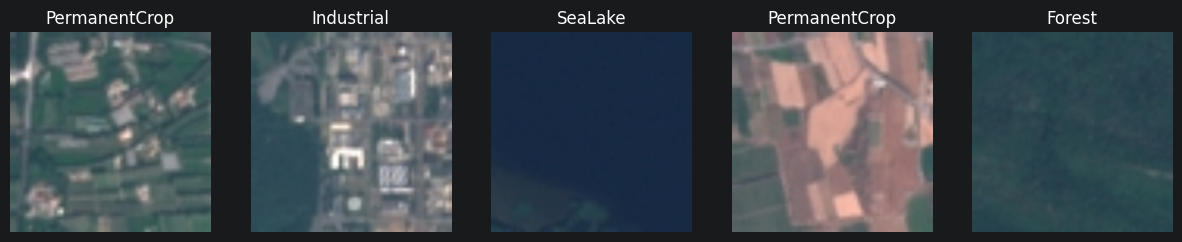

In [2]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i] * std + mean          # undo Normalize
    img = img.permute(1, 2, 0).clamp(0, 1)  # C,H,W -> H,W,C and clip to [0,1]
    axes[i].imshow(img)
    axes[i].set_title(full.classes[labels[i]])   # label index -> class name
    axes[i].axis("off")
plt.show()

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet18(weights="IMAGENET1K_V1")   # pretrained on ImageNet
for p in model.parameters():
    p.requires_grad = False                         # FREEZE the backbone (keep its learned features)
model.fc = nn.Linear(model.fc.in_features, 10)      # NEW trainable head: 10 EuroSAT classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()                   # standard loss for multi-class classification
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)   # train ONLY the new head

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


In [4]:
for epoch in range(5):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)   # move batch to GPU

        # TODO 1: optimizer.zero_grad()      -> clear old gradients (PyTorch accumulates them)
        optimizer.zero_grad()
        # TODO 2: outputs = model(images)     -> forward pass, get predictions (logits)
        outputs = model(images)

        # TODO 3: loss = criterion(outputs, labels)   -> how wrong were we?
        loss = criterion(outputs, labels)
        # TODO 4: loss.backward()             -> backprop: compute gradients
        loss.backward()
        # TODO 5: optimizer.step()            -> update the weights
        optimizer.step()

    # ---- validation after each epoch ----
    model.eval()
    correct = total = 0
    with torch.no_grad():                       # no gradients needed for evaluation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)     # pick the highest-scoring class
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    print(f"epoch {epoch+1}: val acc = {correct/total:.3f}")

epoch 1: val acc = 0.895
epoch 2: val acc = 0.914
epoch 3: val acc = 0.920
epoch 4: val acc = 0.924
epoch 5: val acc = 0.926


                      precision    recall  f1-score   support

          AnnualCrop       0.89      0.96      0.92       323
              Forest       0.98      0.97      0.97       297
HerbaceousVegetation       0.88      0.95      0.91       291
             Highway       0.94      0.79      0.86       243
          Industrial       0.95      0.95      0.95       227
             Pasture       0.97      0.91      0.94       216
       PermanentCrop       0.94      0.86      0.90       253
         Residential       0.95      0.99      0.97       284
               River       0.86      0.89      0.87       246
             SeaLake       0.98      0.99      0.98       320

            accuracy                           0.93      2700
           macro avg       0.93      0.93      0.93      2700
        weighted avg       0.93      0.93      0.93      2700



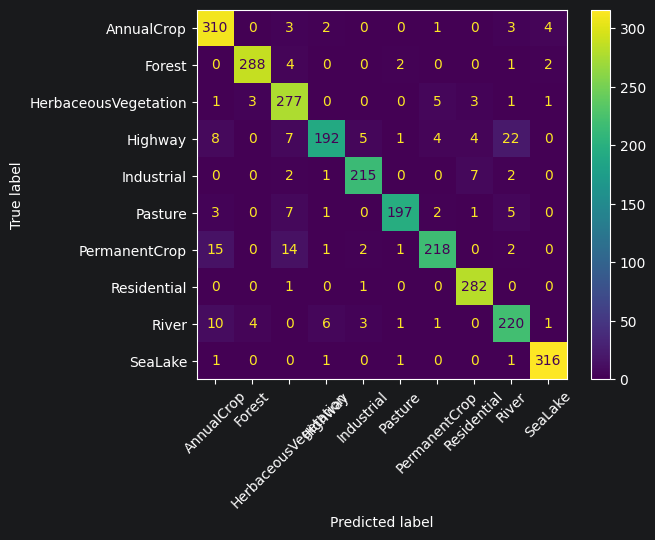

In [8]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu()      # move preds back to CPU for sklearn
        # TODO 1: y_pred.extend(preds.tolist())
        y_pred.extend(preds.tolist())
        # TODO 2: y_true.extend(labels.tolist())
        y_true.extend(labels.tolist())

print(classification_report(y_true, y_pred, target_names=full.classes))
# TODO 3: ConfusionMatrixDisplay.from_predictions(
#             y_true, y_pred, display_labels=full.classes, xticks_rotation=45)
ConfusionMatrixDisplay.from_predictions(
             y_true, y_pred, display_labels=full.classes, xticks_rotation=45)